# **Week 02: ERP Data Analysis 😁**

The objective of this assignment is to create and manage a centralized SQLite database by importing and organizing financial data from CSV files. It also aims to use SQL queries and joins to analyze sales, customers, invoices, and payments. Finally, the results will be used to answer management questions and create visualizations.

In [2]:
#Import the libraries
import pandas as pd
import sqlite3 #Provides SQLite database functionality.
import matplotlib.pyplot as plt

Task 1: Create the Database

In [3]:
#Create a connection to SQLite
conn = sqlite3.connect("financial_analytics.db")

In [4]:
# Enable foreign keys to enforce table relationships.
# SQLite does not enforce them by default.
conn.execute("PRAGMA foreign_keys = ON")

In [5]:
#Create the customers table(an empty table for now)
conn.execute("""
CREATE TABLE customers (
    customer_id TEXT PRIMARY KEY,
    first_name TEXT,
    last_name TEXT,
    email TEXT,
    city TEXT,
    country TEXT,
    signup_date TEXT
)
""")

In [6]:
#Create the products table
conn.execute("""
CREATE TABLE products (
    product_id TEXT PRIMARY KEY,
    product_name TEXT,
    category TEXT,
    unit_cost REAL,
    unit_price REAL,
    stock_quantity INTEGER
)
""")

In [7]:
#Create the invoices table
conn.execute("""
CREATE TABLE invoices (
    invoice_id TEXT PRIMARY KEY,
    customer_id TEXT,
    invoice_date TEXT,
    due_date TEXT,
    subtotal REAL,
    tax_amount REAL,
    invoice_value REAL,
    FOREIGN KEY (customer_id)
        REFERENCES customers(customer_id)
)
""")

In [8]:
#Create the sales table
conn.execute("""
CREATE TABLE sales (
    sale_id TEXT PRIMARY KEY,
    invoice_id TEXT,
    product_id TEXT,
    sale_date TEXT,
    quantity INTEGER,
    unit_price REAL,
    discount_rate REAL,
    revenue REAL,

    FOREIGN KEY (invoice_id)
        REFERENCES invoices(invoice_id),

    FOREIGN KEY (product_id)
        REFERENCES products(product_id)
)
""")

In [9]:
#Create the payments table
conn.execute("""
CREATE TABLE payments (
    payment_id TEXT PRIMARY KEY,
    invoice_id TEXT,
    payment_date TEXT,
    payment_method TEXT,
    amount_paid REAL,

    FOREIGN KEY (invoice_id)
        REFERENCES invoices(invoice_id)
)
""")

Task 2: Load the Data

In [10]:
# Load datasets: loads each CSV into a Pandas DataFrame stored in Python variables.
base_url = "https://raw.githubusercontent.com/engrahmanimanel/-ERP-Data-Analysis/main/week01/"

customers = pd.read_csv(base_url + "customers.csv")
products = pd.read_csv(base_url + "products.csv")
sales = pd.read_csv(base_url + "sales.csv")
invoices = pd.read_csv(base_url + "invoices.csv")
payments = pd.read_csv(base_url + "payments.csv")

In [13]:
#Insert the data into SQLite. to_sql: A Pandas method that writes a DataFrame into an SQL database.
customers.to_sql(
    "customers",
    conn,
    if_exists="append", #append Add new rows to the existing table.
    index=False #Do not save the DataFrame's index as an extra SQL column.
)
products.to_sql(
    "products",
    conn,
    if_exists="append",
    index=False
)
invoices.to_sql(
    "invoices",
    conn,
    if_exists="append",
    index=False
)
sales.to_sql(
    "sales",
    conn,
    if_exists="append",
    index=False
)
payments.to_sql(
    "payments",
    conn,
    if_exists="append",
    index=False
)

IntegrityError: UNIQUE constraint failed: customers.customer_id

In [14]:
#save changes to_sql() → generally doesn't need conn.commit() with SQLite. but we add it on case.
conn.commit()

In [15]:
#count how many records (rows) exist in multiple tables and display the results together.
query = """
SELECT 'customers' AS table_name, COUNT(*) AS records
FROM customers

UNION ALL

SELECT 'products', COUNT(*)
FROM products

UNION ALL

SELECT 'sales', COUNT(*)
FROM sales

UNION ALL

SELECT 'invoices', COUNT(*)
FROM invoices

UNION ALL

SELECT 'payments', COUNT(*)
FROM payments
"""

In [ ]:
pd.read_sql_query(query, conn)

,table_name,records
0,customers,250
1,products,21
2,sales,2925
3,invoices,1200
4,payments,1296


In [18]:
len(customers)
len(products)
len(sales)
len(invoices)
len(payments)


1296

Task 3: Basic SQL Queries

In [20]:
#Total revenue
result = pd.read_sql_query("""
SELECT SUM(revenue) AS total_revenue
FROM sales;""",conn)
print(result)

   total_revenue
0     2923661.35


In [21]:
#Total number of transactions
#COUNT(*)Counts the total number of rows in the table.
result = pd.read_sql_query("""
    SELECT COUNT(*) AS total_transactions
    FROM sales;
""", conn)

print(result)

   total_transactions
0                2925


In [22]:
#Average transaction value
result = pd.read_sql_query("""
SELECT AVG(revenue) AS average_transaction_value
FROM sales;
""", conn)
print(result)

   average_transaction_value
0                 999.542342


In [23]:
#Total invoice value
result = pd.read_sql_query("""
SELECT SUM(invoice_value) AS total_invoice_value
FROM invoices;
""", conn)
print(result)

   total_invoice_value
0           3508393.49


In [24]:
#Total payments
result = pd.read_sql_query("""
SELECT SUM(amount_paid) AS total_payments
FROM payments;
""", conn)
print(result)

   total_payments
0      3157549.78


Task 4: SQL Joins

In [33]:
#These queries combine data from different tables into one result.
#c is an alias (nickname) for customers.
#1st join connects customers (c) with invoices (i) using customer_id.
#2nd join connects invoices (i) with sales (s) using invoice_id.
customers_sales = pd.read_sql_query("""
SELECT c.customer_id, c.first_name, c.last_name,
       s.sale_id, s.invoice_id, s.sale_date, s.revenue
FROM customers c
JOIN invoices i ON c.customer_id = i.customer_id
JOIN sales s ON i.invoice_id = s.invoice_id
""", conn)
print("Customers + Sales")
display(customers_sales.head())

Customers + Sales


,customer_id,first_name,last_name,sale_id,invoice_id,sale_date,revenue
0,C0035,Richard,Smith,S000001,INV00001,2024-05-12,1415.73
1,C0164,Robert,Taylor,S000002,INV00002,2025-10-03,1999.84
2,C0164,Robert,Taylor,S000003,INV00002,2025-10-03,566.41
3,C0164,Robert,Taylor,S000004,INV00002,2025-10-03,935.50
4,C0164,Robert,Taylor,S000005,INV00002,2025-10-03,1323.35


In [34]:
products_sales = pd.read_sql_query("""
SELECT p.product_id, p.product_name, p.category,
       s.sale_id, s.invoice_id, s.quantity, s.revenue
FROM products p
JOIN sales s ON p.product_id = s.product_id
""", conn)
print("Products + Sales")
display(products_sales.head())

Products + Sales


,product_id,product_name,category,sale_id,invoice_id,quantity,revenue
0,P009,Notebook Pack,Office,S000001,INV00001,3,1415.73
1,P013,Air Purifier,Home,S000002,INV00002,4,1999.84
2,P019,Power Bank,Accessories,S000003,INV00002,2,566.41
3,P006,Mouse,Electronics,S000004,INV00002,5,935.50
4,P002,Wireless Headphones,Electronics,S000005,INV00002,4,1323.35


In [35]:
invoices_customers = pd.read_sql_query("""
SELECT i.invoice_id, i.invoice_value,
       c.customer_id, c.first_name, c.last_name
FROM invoices i
JOIN customers c ON i.customer_id = c.customer_id
""", conn)
print("Invoices + Customers")
display(invoices_customers.head())

Invoices + Customers


,invoice_id,invoice_value,customer_id,first_name,last_name
0,INV00001,1698.88,C0035,Richard,Smith
1,INV00002,5790.12,C0164,Robert,Taylor
2,INV00003,1066.82,C0140,Joseph,Moore
3,INV00004,1514.51,C0244,Elizabeth,Martinez
4,INV00005,1159.07,C0212,James,Smith


In [36]:
#LEFT JOIN keeps ALL invoices, even if they have no payment.
invoices_payments = pd.read_sql_query("""
SELECT i.invoice_id, i.invoice_value,
       p.payment_id, p.payment_date, p.payment_method, p.amount_paid
FROM invoices i
LEFT JOIN payments p ON i.invoice_id = p.invoice_id
""", conn)
print("Invoices + Payments")
display(invoices_payments.head())

Invoices + Payments


,invoice_id,invoice_value,payment_id,payment_date,payment_method,amount_paid
0,INV00001,1698.88,PAY000001,2024-05-13,Credit Card,1698.88
1,INV00002,5790.12,PAY000002,2025-10-09,Credit Card,2588.16
2,INV00003,1066.82,PAY000003,2025-03-20,Cash,1066.82
3,INV00004,1514.51,PAY000004,2024-10-02,Cash,1514.51
4,INV00005,1159.07,PAY000005,2025-09-18,Credit Card,1159.07


## Task 5: Management questions

In [27]:
#A JOIN It does not permanently combine the tables in the database.
#The top 5 customers by revenue.
top_customers = pd.read_sql_query("""
SELECT c.customer_id,
       c.first_name || ' ' || c.last_name AS customer_name,
       SUM(s.revenue) AS total_revenue
FROM customers c
JOIN invoices i ON c.customer_id = i.customer_id
JOIN sales s ON i.invoice_id = s.invoice_id
GROUP BY c.customer_id, c.first_name, c.last_name
ORDER BY total_revenue DESC
LIMIT 5
""", conn)
display(top_customers)

,customer_id,customer_name,total_revenue
0,C0161,Susan Jackson,97832.19
1,C0109,Thomas Williams,69524.23
2,C0099,Linda Lopez,61980.79
3,C0202,Joseph Thomas,57511.51
4,C0222,Thomas Anderson,52121.41


In [28]:
#The top 5 products by revenue.
top_products = pd.read_sql_query("""
SELECT p.product_id, p.product_name,
       SUM(s.revenue) AS total_revenue
FROM products p
JOIN sales s ON p.product_id = s.product_id
GROUP BY p.product_id, p.product_name
ORDER BY total_revenue DESC
LIMIT 5
""", conn)
display(top_products)

,product_id,product_name,total_revenue
0,P017,USB-C Cable,277920.24
1,P020,Phone Stand,223630.64
2,P001,Laptop,222538.44
3,P003,Smartphone,220729.82
4,P009,Notebook Pack,217828.68


In [29]:
#Monthly revenue.
#strftime() extracts parts of a date.
#GROUP BY tells SQL to put rows with the same value into groups.
monthly_revenue = pd.read_sql_query("""
SELECT strftime('%Y-%m', sale_date) AS month,
       SUM(revenue) AS monthly_revenue
FROM sales
GROUP BY strftime('%Y-%m', sale_date)
ORDER BY month
""", conn)
display(monthly_revenue)

,month,monthly_revenue
0,2024-01,135825.19
1,2024-02,117577.34
2,2024-03,102469.35
3,2024-04,92262.28
4,2024-05,133703.83
5,2024-06,136152.06
6,2024-07,120466.07
7,2024-08,105766.41
8,2024-09,133686.96
9,2024-10,118122.07


In [30]:
#Customers have unpaid invoices.
#COALESCE(value, replacement) means if value is NULL, use replacement.
#HAVING This removes invoices whose unpaid amount is zero.
unpaid_invoices = pd.read_sql_query("""
SELECT c.customer_id,
       c.first_name || ' ' || c.last_name AS customer_name,
       i.invoice_id,
       i.invoice_value,
       COALESCE(SUM(p.amount_paid), 0) AS total_paid,
       i.invoice_value - COALESCE(SUM(p.amount_paid), 0) AS unpaid_amount
FROM customers c
JOIN invoices i ON c.customer_id = i.customer_id
LEFT JOIN payments p ON i.invoice_id = p.invoice_id
GROUP BY c.customer_id, c.first_name, c.last_name, i.invoice_id, i.invoice_value
HAVING i.invoice_value - COALESCE(SUM(p.amount_paid), 0) > 0
ORDER BY unpaid_amount DESC
""", conn)
display(unpaid_invoices.head())

,customer_id,customer_name,invoice_id,invoice_value,total_paid,unpaid_amount
0,C0163,Karen Taylor,INV00576,6642.28,0.0,6642.28
1,C0187,Jessica Davis,INV00860,6373.03,0.0,6373.03
2,C0231,Sarah Lopez,INV00158,6047.76,0.0,6047.76
3,C0203,Linda Martin,INV00342,6017.77,0.0,6017.77
4,C0108,James Anderson,INV00099,5977.04,0.0,5977.04


In [31]:
#Average payment delay.
avg_payment_delay = pd.read_sql_query("""
SELECT AVG(julianday(p.payment_date) - julianday(i.invoice_date)) AS avg_payment_delay_days
FROM invoices i
JOIN payments p ON i.invoice_id = p.invoice_id
WHERE p.payment_date IS NOT NULL
  AND i.invoice_date IS NOT NULL
""", conn)
display(avg_payment_delay)

,avg_payment_delay_days
0,29.797068


In [32]:
#Product categories that generate the most revenue.
category_revenue = pd.read_sql_query("""
SELECT p.category, SUM(s.revenue) AS total_revenue
FROM products p
JOIN sales s ON p.product_id = s.product_id
GROUP BY p.category
ORDER BY total_revenue DESC
""", conn)
display(category_revenue)

,category,total_revenue
0,Accessories,937452.70
1,Electronics,813099.34
2,Home,650593.05
3,Office,522516.26


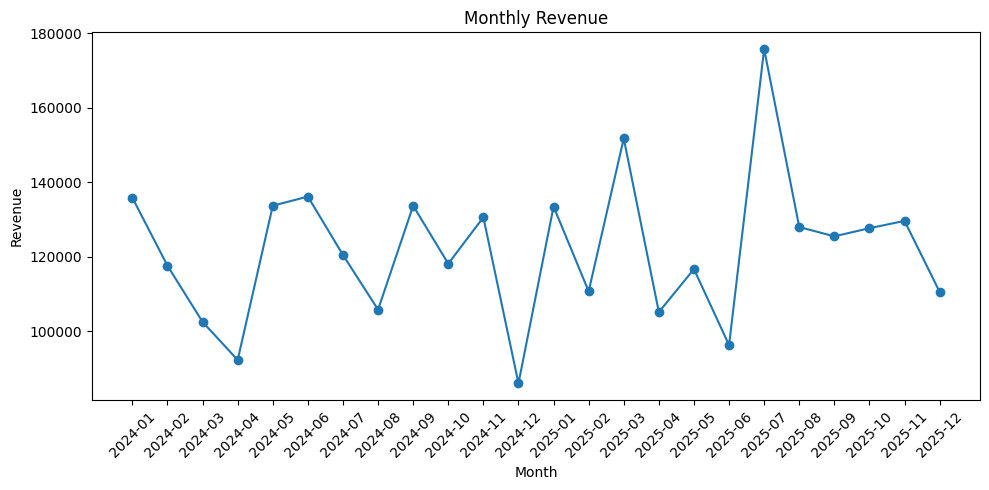

In [ ]:
# Visualization 1: Monthly revenue
plt.figure(figsize=(10, 5))
plt.plot(monthly_revenue["month"], monthly_revenue["monthly_revenue"], marker="o")
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

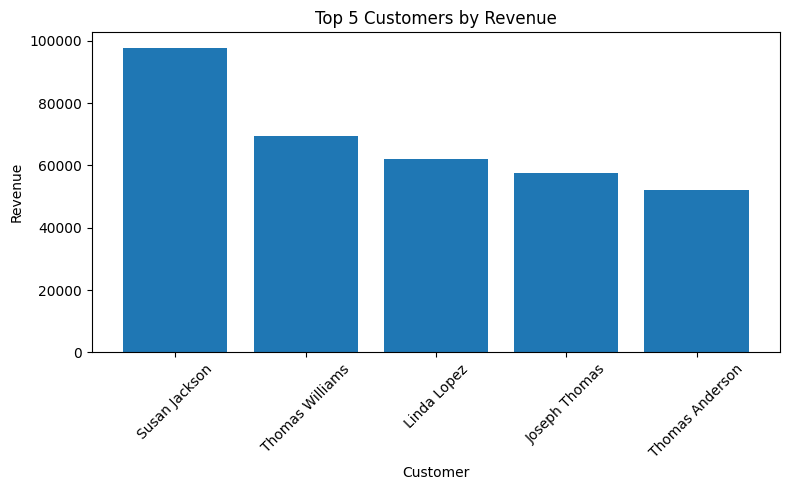

In [ ]:
# Visualization 2: Top 5 customers by revenue
plt.figure(figsize=(8, 5))
plt.bar(top_customers["customer_name"], top_customers["total_revenue"])
plt.title("Top 5 Customers by Revenue")
plt.xlabel("Customer")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

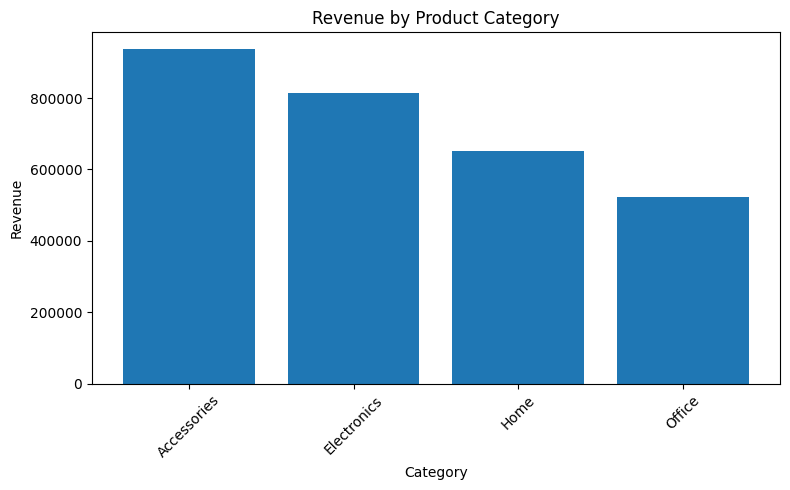

In [ ]:
# Visualization 3: Revenue by product category
plt.figure(figsize=(8, 5))
plt.bar(category_revenue["category"], category_revenue["total_revenue"])
plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

conn.close()